In [47]:
# ================================================
# # Project 1: Lending Club Loan Analysis
# **Analyst:** Sachin Malee
# **Dataset:** Lending Club Loan Data (Kaggle)
# **Rows:** 1,00,000 | **Columns:** 15
# **Tools:** Python, Pandas, Matplotlib, Seaborn
# ================================================

In [56]:
# ================================================
# Libraries
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [57]:
# ================================================
# Load Data
# ================================================
path = "C:/Users/srmal/OneDrive/Desktop/Lending Club Loan Data/"

df = pd.read_csv(
    path + 'loan_clean.csv',
    low_memory=False)

print(f"✅ Data loaded!")
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nNull Values:\n{df.isnull().sum()}")
print(f"\nLoan Status:\n"
      f"{df['loan_status'].value_counts()}")

✅ Data loaded!
Rows:    100,000
Columns: 15

Columns: ['loan_id', 'loan_amount', 'funded_amount', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_income', 'loan_status', 'purpose', 'addr_state', 'dti', 'issue_date']

Data Types:
loan_id           float64
loan_amount         int64
funded_amount       int64
term               object
int_rate          float64
grade              object
sub_grade          object
emp_length         object
home_ownership     object
annual_income     float64
loan_status        object
purpose            object
addr_state         object
dti               float64
issue_date         object
dtype: object

Null Values:
loan_id           100000
loan_amount            0
funded_amount          0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length          6442
home_ownership         0
annual_income          0
loan_status            0
purpose                0
addr_state         

In [58]:
# ================================================
# Data Cleaning
# ================================================

print("BEFORE cleaning:")
print(f"  Rows:  {len(df):,}")
print(f"  Nulls: {df.isnull().sum().sum()}")

# Duplicates remove
df = df.drop_duplicates()

# Date column fix
df['issue_date'] = pd.to_datetime(
    df['issue_date'], errors='coerce')

df['issue_year']  = df['issue_date'].dt.year
df['issue_month'] = df['issue_date'].dt.month
df['issue_month_name'] = (
    df['issue_date'].dt.month_name())

# Nulls fill karo
df['emp_length'].fillna(
    'Unknown', inplace=True)
df['dti'].fillna(
    df['dti'].median(), inplace=True)

# Income outliers handle karo
df = df[df['annual_income'] < 500000]
df = df[df['dti'].between(0, 100)]

# New columns add karo
df['loan_to_income'] = (
    df['loan_amount'] /
    df['annual_income'] * 100
).round(2)

df['is_default'] = (
    df['loan_status'] == 'Charged Off'
).astype(int)

df['grade_num'] = df['grade'].map(
    {'A':1,'B':2,'C':3,'D':4,
     'E':5,'F':6,'G':7})

df['income_band'] = pd.cut(
    df['annual_income'],
    bins=[0, 40000, 80000,
          150000, float('inf')],
    labels=['Low','Medium',
            'High','Very High'])

df['dti_band'] = pd.cut(
    df['dti'],
    bins=[0, 10, 20, 30, 100],
    labels=['Low','Medium',
            'High','Very High'])

df['loan_band'] = pd.cut(
    df['loan_amount'],
    bins=[0, 5000, 15000,
          25000, float('inf')],
    labels=['Small','Medium',
            'Large','Very Large'])

print("\nAFTER cleaning:")
print(f"  Rows:       {len(df):,}")
print(f"  Nulls:      "
      f"{df.isnull().sum().sum()}")
print(f"  Defaults:   "
      f"{df['is_default'].sum():,} "
      f"({df['is_default'].mean()*100:.1f}%)")
print("\n✅ New columns added!")

BEFORE cleaning:
  Rows:  100,000
  Nulls: 106521

AFTER cleaning:
  Rows:       99,661
  Nulls:      99821
  Defaults:   11,564 (11.6%)

✅ New columns added!


In [61]:
# ================================================
# Key Insights
# ================================================

print("="*55)
print("📊 LENDING CLUB — KEY INSIGHTS")
print("="*55)

total = len(df)
defaults = df['is_default'].sum()

print(f"\n📋 Total Loans:       {total:,}")
print(f"💰 Total Amount:      "
      f"${df['loan_amount'].sum():,.0f}")
print(f"📊 Default Rate:      "
      f"{defaults/total*100:.1f}%")
print(f"✅ Fully Paid Rate:   "
      f"{(df['loan_status']=='Fully Paid').mean()*100:.1f}%")
print(f"📈 Avg Interest Rate: "
      f"{df['int_rate'].mean():.1f}%")
print(f"💵 Avg Loan Amount:   "
      f"${df['loan_amount'].mean():,.0f}")
print(f"👤 Avg Annual Income: "
      f"${df['annual_income'].mean():,.0f}")
print(f"📉 Avg DTI:           "
      f"{df['dti'].mean():.1f}")

print("\n🎯 Default Rate by Grade:")
grade_def = (df.groupby('grade')
    ['is_default'].mean()*100
    ).round(1)
for g, r in grade_def.items():
    bar = '█' * int(r/2)
    print(f"   {g}: {r}% {bar}")

print("\n🏦 Top 3 Loan Purposes:")
top_purpose = (df.groupby('purpose')
    ['loan_amount'].count()
    .sort_values(ascending=False)
    .head(3))
for p, c in top_purpose.items():
    print(f"   {p}: {c:,} loans")

print("\n⚠️ Highest Default Purpose:")
purpose_def = (df.groupby('purpose')
    ['is_default'].mean()*100
    ).sort_values(ascending=False)
print(f"   {purpose_def.index[0]}: "
      f"{purpose_def.iloc[0]:.1f}%")

📊 LENDING CLUB — KEY INSIGHTS

📋 Total Loans:       99,661
💰 Total Amount:      $1,501,473,800
📊 Default Rate:      11.6%
✅ Fully Paid Rate:   46.1%
📈 Avg Interest Rate: 13.1%
💵 Avg Loan Amount:   $15,066
👤 Avg Annual Income: $76,498
📉 Avg DTI:           18.6

🎯 Default Rate by Grade:
   A: 3.1% █
   B: 7.8% ███
   C: 12.8% ██████
   D: 18.6% █████████
   E: 25.8% ████████████
   F: 33.1% ████████████████
   G: 36.3% ██████████████████

🏦 Top 3 Loan Purposes:
   debt_consolidation: 56,189 loans
   credit_card: 22,746 loans
   home_improvement: 6,689 loans

⚠️ Highest Default Purpose:
   educational: 22.2%


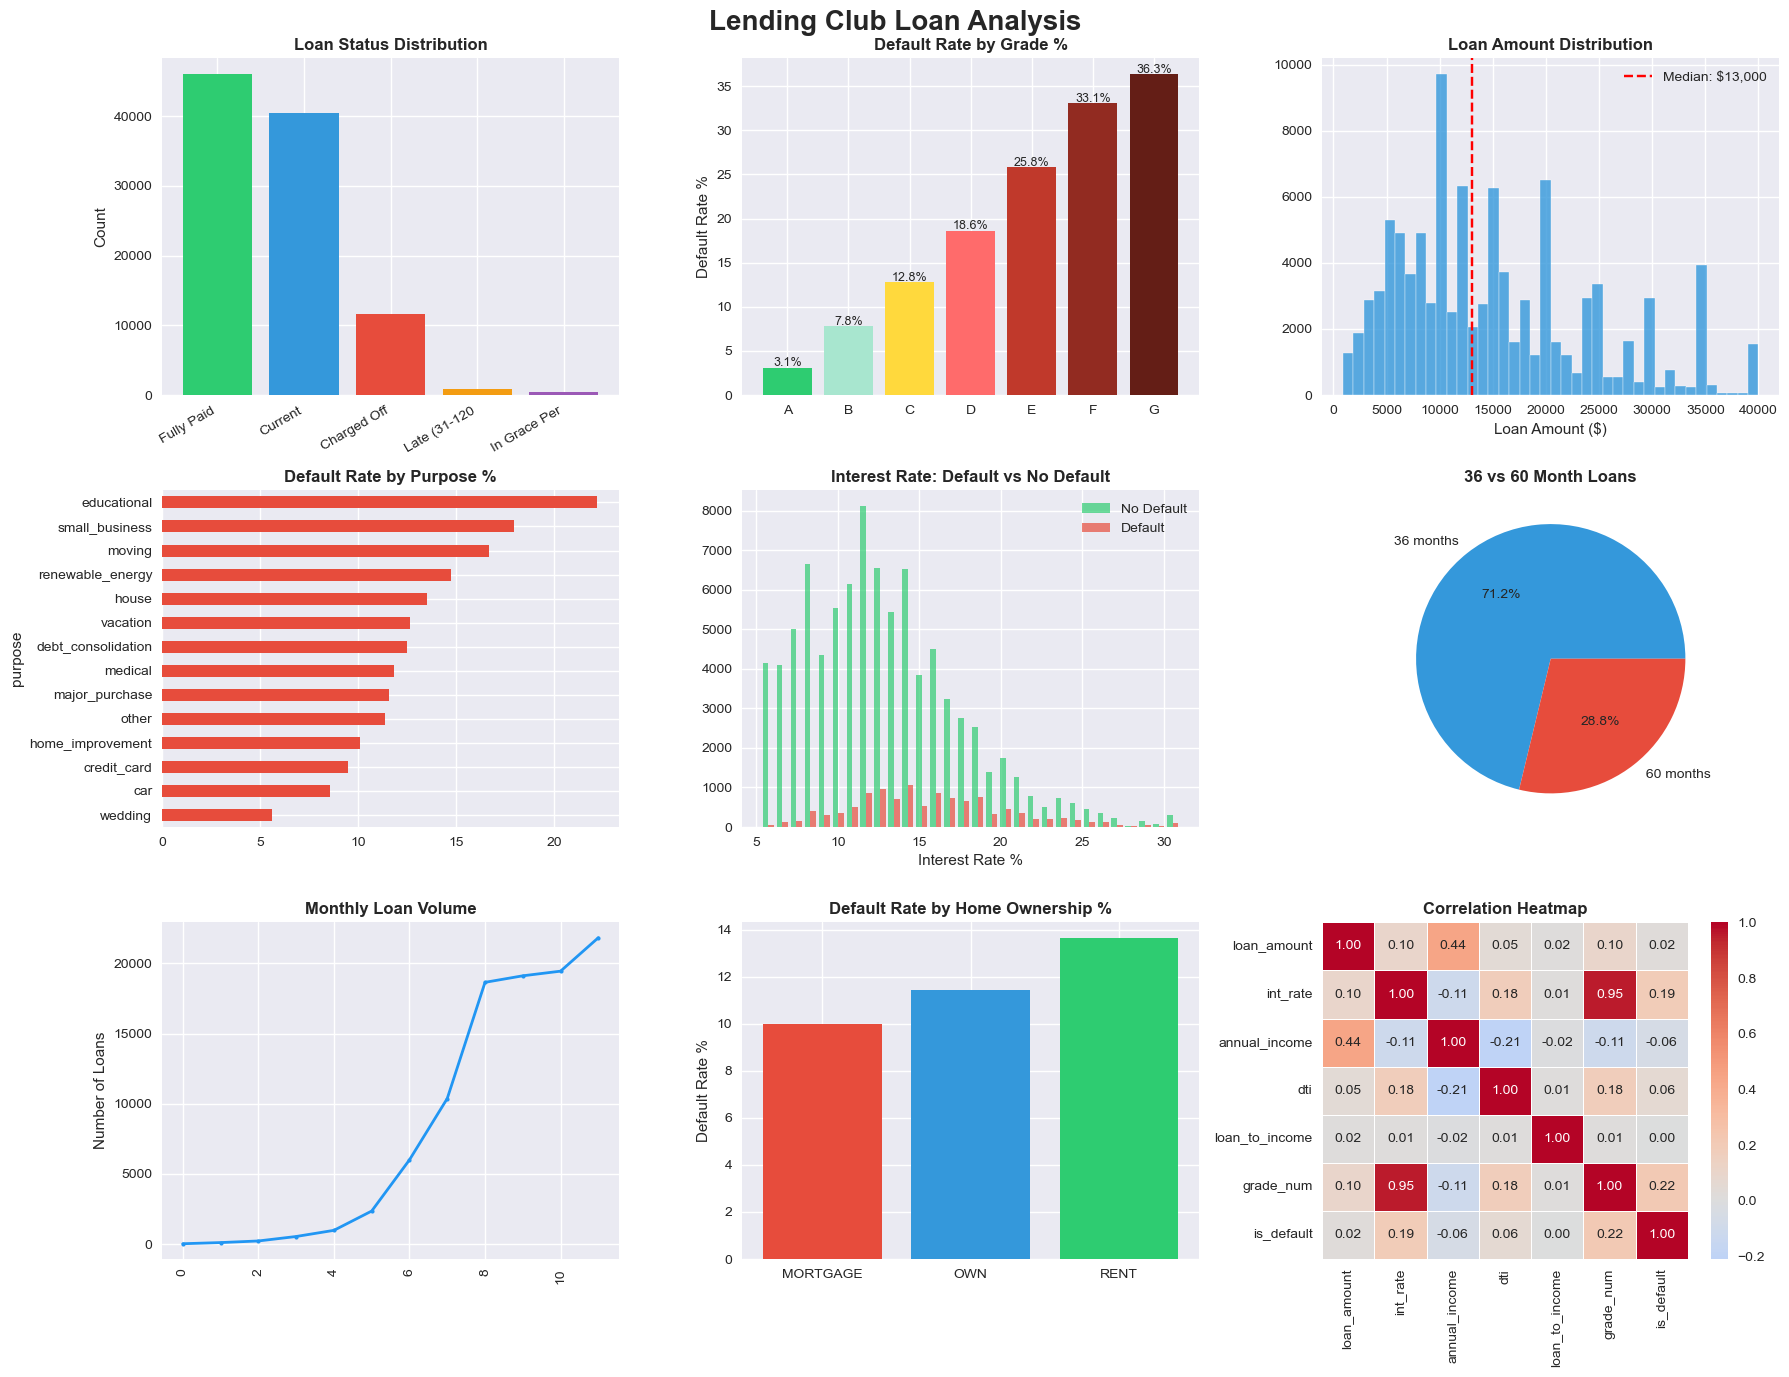

✅ All graphs saved!


In [62]:
# ================================================
# Visualizations
# ================================================

fig, axes = plt.subplots(3, 3,
    figsize=(18, 14))
fig.suptitle(
    'Lending Club Loan Analysis',
    fontsize=20, fontweight='bold')

# Graph 1 — Loan Status Distribution
ax1 = axes[0,0]
status = (df['loan_status']
    .value_counts().head(5))
colors1 = ['#2ecc71','#3498db','#e74c3c',
           '#f39c12','#9b59b6']
ax1.bar(range(len(status)),
        status.values,
        color=colors1)
ax1.set_xticks(range(len(status)))
ax1.set_xticklabels(
    [s[:12] for s in status.index],
    rotation=30, ha='right')
ax1.set_title('Loan Status Distribution',
              fontweight='bold')
ax1.set_ylabel('Count')

# Graph 2 — Default Rate by Grade
ax2 = axes[0,1]
grade_def = (df.groupby('grade')
    ['is_default'].mean()*100
    ).sort_index()
bar_colors = ['#2ecc71','#a8e6cf',
              '#ffd93d','#ff6b6b',
              '#c0392b','#922b21','#641e16']
ax2.bar(grade_def.index,
        grade_def.values,
        color=bar_colors)
ax2.set_title('Default Rate by Grade %',
              fontweight='bold')
ax2.set_ylabel('Default Rate %')
for i, (g, v) in enumerate(
        grade_def.items()):
    ax2.text(i, v+0.2,
             f'{v:.1f}%',
             ha='center', fontsize=9)

# Graph 3 — Loan Amount Distribution
ax3 = axes[0,2]
ax3.hist(df['loan_amount'],
         bins=40, color='#3498db',
         edgecolor='white', alpha=0.8)
ax3.axvline(df['loan_amount'].median(),
            color='red',
            linestyle='--',
            label=f"Median: "
                  f"${df['loan_amount'].median():,.0f}")
ax3.set_title('Loan Amount Distribution',
              fontweight='bold')
ax3.set_xlabel('Loan Amount ($)')
ax3.legend()

# Graph 4 — Default by Purpose
ax4 = axes[1,0]
purpose_def = (df.groupby('purpose')
    ['is_default'].mean()*100
    ).sort_values(ascending=True)
purpose_def.plot(kind='barh',
                 ax=ax4,
                 color='#e74c3c')
ax4.set_title('Default Rate by Purpose %',
              fontweight='bold')

# Graph 5 — Interest Rate Distribution
ax5 = axes[1,1]
ax5.hist(
    [df[df['is_default']==0]['int_rate'],
     df[df['is_default']==1]['int_rate']],
    bins=30,
    label=['No Default','Default'],
    color=['#2ecc71','#e74c3c'],
    alpha=0.7)
ax5.set_title(
    'Interest Rate: Default vs No Default',
    fontweight='bold')
ax5.set_xlabel('Interest Rate %')
ax5.legend()

# Graph 6 — Loan Term Distribution
ax6 = axes[1,2]
term_data = df['term'].value_counts()
ax6.pie(term_data.values,
        labels=term_data.index,
        autopct='%1.1f%%',
        colors=['#3498db','#e74c3c'])
ax6.set_title('36 vs 60 Month Loans',
              fontweight='bold')

# Graph 7 — Monthly Loan Volume
ax7 = axes[2,0]
monthly = (df.groupby(
    ['issue_year','issue_month'])
    ['loan_amount'].count()
    .reset_index())
monthly['period'] = (
    monthly['issue_year'].astype(str)
    + '-' +
    monthly['issue_month']
    .astype(str).str.zfill(2))
monthly_sorted = monthly.sort_values(
    ['issue_year','issue_month'])
ax7.plot(
    range(len(monthly_sorted)),
    monthly_sorted['loan_amount'],
    color='#2196F3',
    linewidth=2, marker='o',
    markersize=3)
ax7.set_title('Monthly Loan Volume',
              fontweight='bold')
ax7.set_ylabel('Number of Loans')
ax7.tick_params(axis='x',
                rotation=90)

# Graph 8 — Home Ownership vs Default
ax8 = axes[2,1]
home_def = (df[df['home_ownership']
    .isin(['RENT','MORTGAGE','OWN'])]
    .groupby('home_ownership')
    ['is_default'].mean()*100)
ax8.bar(home_def.index,
        home_def.values,
        color=['#e74c3c','#3498db','#2ecc71'])
ax8.set_title(
    'Default Rate by Home Ownership %',
    fontweight='bold')
ax8.set_ylabel('Default Rate %')

# Graph 9 — Correlation Heatmap
ax9 = axes[2,2]
num_cols = ['loan_amount','int_rate',
            'annual_income','dti',
            'loan_to_income',
            'grade_num','is_default']
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', ax=ax9,
    linewidths=0.5, center=0)
ax9.set_title('Correlation Heatmap',
              fontweight='bold')

plt.tight_layout()
plt.savefig(
    'lending_club_analysis.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ All graphs saved!")

In [67]:
# ================================================
# CELL 7 — Save Clean Data
# ================================================
df.to_csv(
    path + 'loan_cleaned_final.csv',
    index=False)
print(f"✅ Clean data saved!")
print(f"   Rows: {len(df):,}")
print(f"   Cols: {len(df.columns)}")

✅ Clean data saved!
   Rows: 99,661
   Cols: 24
